Nama : Ken Foster Morintoh\
NIM  : 672020175


Classification
1. knn nearest neighbors 
2. random forest 
3. naive bayes
4. decision tree
5. SVM


reff: 
https://www.geeksforgeeks.org/k-nearest-neighbours/

https://www.geeksforgeeks.org/k-nearest-neighbor-algorithm-in-python/

https://colab.research.google.com/drive/1HRAs3taE6Xea1RRfWayGO704Mk1cNEKh#scrollTo=-rMkgHyw9l3B

https://towardsdatascience.com/project-predicting-heart-disease-with-classification-machine-learning-algorithms-fd69e6fdc9d6



In [11]:
import pandas as pd 
import numpy as np
import seaborn as sbs
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

In [5]:
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')



In [6]:
df.head()


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [7]:
X = df.drop(columns = ['DEATH_EVENT'])
y = df['DEATH_EVENT']

In [30]:
y.value_counts()

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [93]:
  
model = KNeighborsClassifier(n_neighbors=4) 
model.fit(X_train, y_train)
print(model.predict(X_test))

[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0]


In [94]:
print(model.score(X_test, y_test)) 

0.55


In [100]:
from sklearn.metrics import classification_report 
from sklearn.ensemble import RandomForestClassifier

model6 = RandomForestClassifier(random_state=42)# get instance of model
model6.fit(X_train, y_train) # Train/Fit model 

y_pred6 = model6.predict(X_test) # get y predictions
print(classification_report(y_test, y_pred6)) # output accuracy

print(model6.score(X_test, y_test)) 

              precision    recall  f1-score   support

           0       0.72      0.94      0.81        35
           1       0.86      0.48      0.62        25

    accuracy                           0.75        60
   macro avg       0.79      0.71      0.72        60
weighted avg       0.78      0.75      0.73        60

0.75


In [99]:
from sklearn.metrics import classification_report 
from sklearn.tree import DecisionTreeClassifier

model5 = DecisionTreeClassifier(random_state=1) # get instance of model
model5.fit(X_train, y_train) # Train/Fit model 

y_pred5 = model5.predict(X_test) # get y predictions
print(classification_report(y_test, y_pred5)) # output accuracy


print(model5.score(X_test, y_test)) 

              precision    recall  f1-score   support

           0       0.64      0.80      0.71        35
           1       0.56      0.36      0.44        25

    accuracy                           0.62        60
   macro avg       0.60      0.58      0.57        60
weighted avg       0.61      0.62      0.60        60

0.6166666666666667


In [13]:
neighbors = np.arange(1,9)
train_accuracy = np.empty(len(neighbors))
test_accuracy = np.empty(len(neighbors))

In [47]:
for i, k in enumerate(neighbors) : 
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    train_accuracy[i] = knn.score(X_train, y_train)
    test_accuracy[i] = knn.score(X_test, y_test)

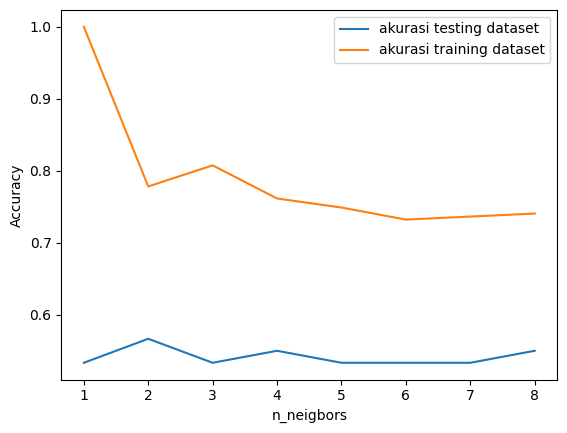

In [49]:
plt.plot(neighbors,test_accuracy, label ="akurasi testing dataset")

plt.plot(neighbors, train_accuracy, label ="akurasi training dataset")

plt.legend()
plt.xlabel('n_neigbors')
plt.ylabel('Accuracy')

plt.show()

In [51]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
print("[INFO] evaluating...")
predictions = knn.predict(X_test)
print(classification_report(y_test, predictions))

print("Test set Accuracy: ", round(accuracy_score(y_test,predictions),2))

[INFO] evaluating...
              precision    recall  f1-score   support

           0       0.57      0.91      0.70        35
           1       0.25      0.04      0.07        25

    accuracy                           0.55        60
   macro avg       0.41      0.48      0.39        60
weighted avg       0.44      0.55      0.44        60

Test set Accuracy:  0.55


In [52]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test, predictions)

Text(95.72222222222221, 0.5, 'Truth')

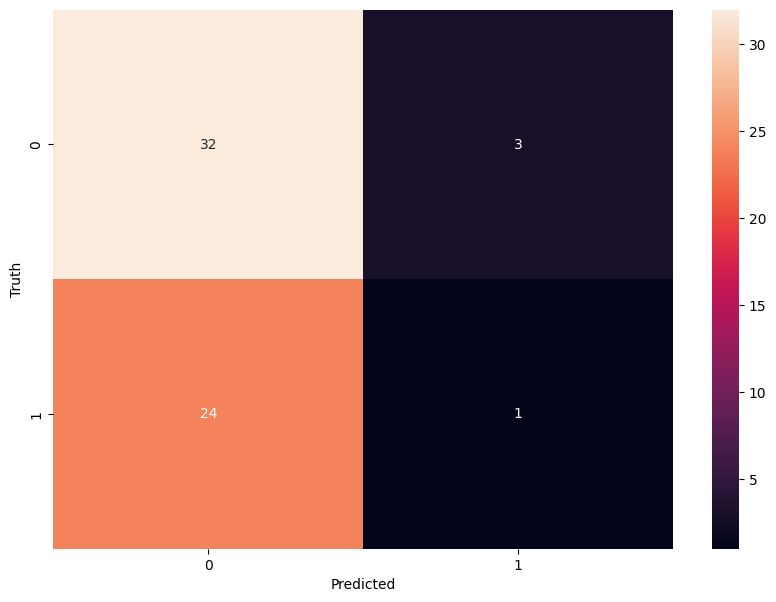

In [26]:
plt.figure (figsize=(10,7))
sbs.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')